# Knowledge Graph Visualizer

This notebook provides comprehensive visualization tools for the RAGAS Knowledge Graph stored in `usecase_data_kg.json`.

## Features:
- 📊 Multiple visualization methods
- 🔍 Interactive exploration
- 📈 Statistical analysis
- 🌐 Network analysis with community detection

---


## Setup and Dependencies


In [30]:
# Install required packages
%pip install networkx matplotlib plotly pandas numpy seaborn


/Users/anilyanamandra/Develop/aie8/AI-Engineering-Bootcamp/07_Synthetic_Data_Generation_and_LangSmith/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [31]:
# Import libraries
import networkx as nx
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import pandas as pd
import numpy as np
import json
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('default')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


## Load Knowledge Graph Data


In [32]:
# Load the knowledge graph JSON file
def load_knowledge_graph(json_file_path):
    """Load knowledge graph from JSON file"""
    with open(json_file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    print(f"📊 Knowledge Graph Statistics:")
    print(f"   • Total Nodes: {len(data['nodes'])}")
    print(f"   • Total Relationships: {len(data.get('relationships', []))}")
    
    # Analyze node types
    node_types = [node['type'] for node in data['nodes']]
    type_counts = Counter(node_types)
    print(f"   • Node Types: {dict(type_counts)}")
    
    # Analyze relationship types if they exist
    if 'relationships' in data and data['relationships']:
        rel_types = [rel.get('type', 'unknown') for rel in data['relationships']]
        rel_type_counts = Counter(rel_types)
        print(f"   • Relationship Types: {dict(rel_type_counts)}")
    
    return data

# Load the knowledge graph
kg_data = load_knowledge_graph('usecase_data_kg.json')


📊 Knowledge Graph Statistics:
   • Total Nodes: 86
   • Total Relationships: 712
   • Node Types: {'document': 81, 'chunk': 5}
   • Relationship Types: {'child': 5, 'next': 1, 'cosine_similarity': 703, 'entities_overlap': 3}


## Method 1: Basic NetworkX Visualization


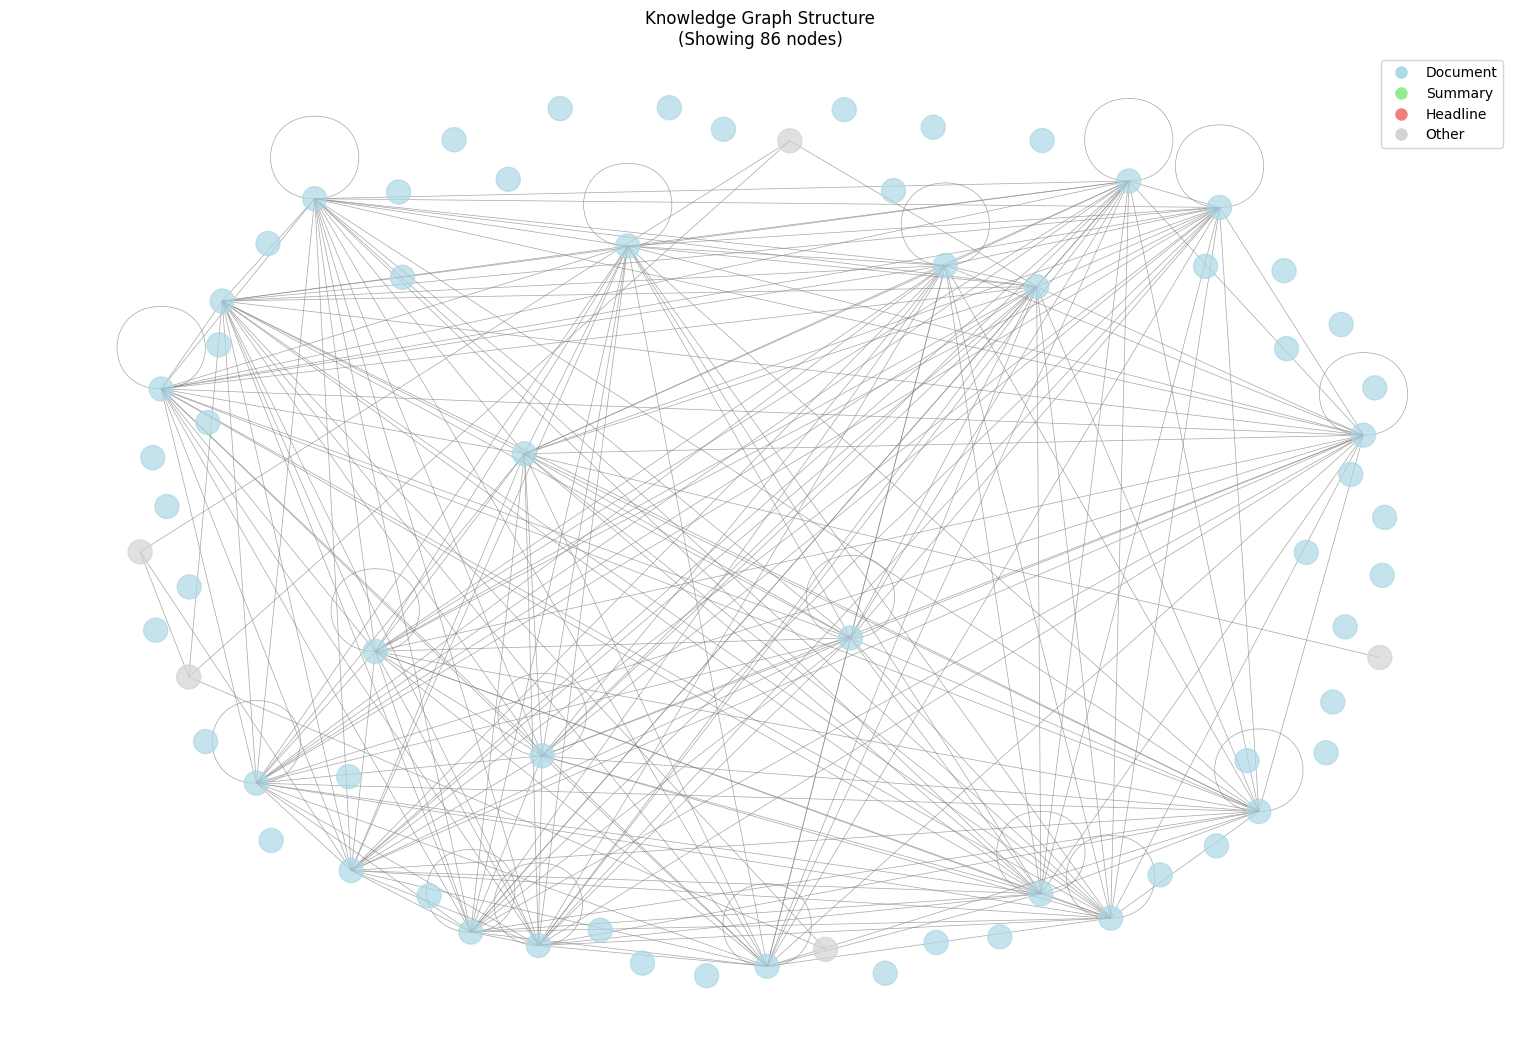

In [33]:
def create_basic_network(kg_data, max_nodes=100):
    """Create a basic network visualization"""
    G = nx.Graph()
    
    # Add nodes (limit for performance)
    nodes_to_plot = kg_data['nodes'][:max_nodes] if len(kg_data['nodes']) > max_nodes else kg_data['nodes']
    
    for node in nodes_to_plot:
        G.add_node(node['id'], 
                  node_type=node['type'],
                  properties=node.get('properties', {}))
    
    # Add relationships if they exist
    if 'relationships' in kg_data and kg_data['relationships']:
        for rel in kg_data['relationships']:
            # Extract source and target IDs from the relationship structure
            source_id = rel.get('source', {}).get('id') if isinstance(rel.get('source'), dict) else rel.get('source')
            target_id = rel.get('target', {}).get('id') if isinstance(rel.get('target'), dict) else rel.get('target')
            
            if source_id and target_id:
                # Check if both nodes are in our plot set
                if any(n['id'] == source_id for n in nodes_to_plot) and any(n['id'] == target_id for n in nodes_to_plot):
                    G.add_edge(source_id, target_id, relationship_type=rel.get('type', 'unknown'))
    
    return G, nodes_to_plot

def plot_basic_network(G, nodes_to_plot, title="Knowledge Graph Structure"):
    """Plot basic network visualization"""
    plt.figure(figsize=(15, 10))
    
    # Use spring layout
    pos = nx.spring_layout(G, k=3, iterations=50, seed=42)
    
    # Color nodes by type
    node_colors = []
    for node in G.nodes():
        node_type = G.nodes[node]['node_type']
        if node_type == 'document':
            node_colors.append('lightblue')
        elif node_type == 'summary':
            node_colors.append('lightgreen')
        elif node_type == 'headline':
            node_colors.append('lightcoral')
        else:
            node_colors.append('lightgray')
    
    # Draw the graph
    nx.draw(G, pos, 
            node_color=node_colors,
            node_size=300,
            with_labels=False,
            font_size=8,
            font_weight='bold',
            edge_color='gray',
            alpha=0.7,
            width=0.5)
    
    # Add legend
    legend_elements = [
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='lightblue', markersize=10, label='Document'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgreen', markersize=10, label='Summary'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='lightcoral', markersize=10, label='Headline'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgray', markersize=10, label='Other')
    ]
    
    plt.legend(handles=legend_elements, loc='upper right')
    plt.title(f"{title}\n(Showing {len(nodes_to_plot)} nodes)")
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    return G

# Create and plot basic network
G_basic, nodes_basic = create_basic_network(kg_data, max_nodes=100)
plot_basic_network(G_basic, nodes_basic)


## Method 2: Interactive Plotly 3D Visualization


In [36]:
def create_interactive_3d_plot(kg_data, max_nodes=200, max_relationships=100):
    """Create interactive 3D visualization"""
    
    # Prepare data
    nodes_to_plot = kg_data['nodes'][:max_nodes] if len(kg_data['nodes']) > max_nodes else kg_data['nodes']
    
    # Create node data with 3D coordinates
    node_data = []
    for i, node in enumerate(nodes_to_plot):
        # Generate 3D coordinates
        theta = 2 * np.pi * i / len(nodes_to_plot)
        radius = 10 + np.random.uniform(-2, 2)
        
        node_info = {
            'id': node['id'],
            'type': node['type'],
            'x': radius * np.cos(theta) + np.random.uniform(-1, 1),
            'y': radius * np.sin(theta) + np.random.uniform(-1, 1),
            'z': np.random.uniform(-5, 5),
            'size': 15 if node['type'] == 'document' else 10,
            'color': 'blue' if node['type'] == 'document' else 'red'
        }
        node_data.append(node_info)
    
    # Create 3D scatter plot
    fig = go.Figure()
    
    # Group nodes by type for better visualization
    type_colors = {'document': 'blue', 'summary': 'green', 'headline': 'red', 'other': 'gray'}
    
    for node_type in set(node['type'] for node in nodes_to_plot):
        type_nodes = [n for n in node_data if n['type'] == node_type]
        
        # Create descriptive names for legend
        type_descriptions = {
            'document': 'Document (Blue) - Original document pages',
            'summary': 'Summary (Green) - AI-generated summaries', 
            'headline': 'Headline (Red) - Extracted headlines',
            'other': 'Other (Gray) - Additional node types'
        }
        
        fig.add_trace(go.Scatter3d(
            x=[n['x'] for n in type_nodes],
            y=[n['y'] for n in type_nodes],
            z=[n['z'] for n in type_nodes],
            mode='markers',
            marker=dict(
                size=[n['size'] for n in type_nodes],
                color=type_colors.get(node_type, 'gray'),
                opacity=0.8
            ),
            text=[f"{n['type']}: {n['id'][:8]}" for n in type_nodes],
            name=type_descriptions.get(node_type, f"{node_type.title()} (Gray)"),
            hovertemplate=f"<b>{node_type.title()}</b><br>ID: %{{text}}<extra></extra>"
        ))
    
    # Add relationships if they exist
    edge_count = 0  # Initialize edge_count
    if 'relationships' in kg_data and kg_data['relationships']:
        relationships_to_plot = kg_data['relationships']
        if max_relationships is not None:
            relationships_to_plot = relationships_to_plot[:max_relationships]
        
        for rel in relationships_to_plot:
            # Extract source and target IDs from the relationship structure
            source_id = rel.get('source', {}).get('id') if isinstance(rel.get('source'), dict) else rel.get('source')
            target_id = rel.get('target', {}).get('id') if isinstance(rel.get('target'), dict) else rel.get('target')
            
            if source_id and target_id:
                source_node = next((n for n in node_data if n['id'] == source_id), None)
                target_node = next((n for n in node_data if n['id'] == target_id), None)
                
                if source_node and target_node:
                    fig.add_trace(go.Scatter3d(
                        x=[source_node['x'], target_node['x'], None],
                        y=[source_node['y'], target_node['y'], None],
                        z=[source_node['z'], target_node['z'], None],
                        mode='lines',
                        line=dict(color='gray', width=2),
                        showlegend=False,
                        hoverinfo='skip'
                    ))
                    edge_count += 1
    
    # Update title to reflect relationship limits
    total_relationships = len(kg_data.get('relationships', []))
    if max_relationships is not None and total_relationships > max_relationships:
        title = f"Interactive Knowledge Graph (3D) - {len(nodes_to_plot)} nodes, {edge_count} relationships (capped at {max_relationships} of {total_relationships})"
    else:
        title = f"Interactive Knowledge Graph (3D) - {len(nodes_to_plot)} nodes, {edge_count} relationships"
    
    fig.update_layout(
        title=title,
        scene=dict(
            xaxis_title="X",
            yaxis_title="Y",
            zaxis_title="Z",
            bgcolor='rgba(0,0,0,0.02)'
        ),
        legend=dict(
            orientation="h",
            yanchor="top",
            y=-0.1,
            xanchor="center",
            x=0.5
        ),
        margin=dict(b=100),  # Add bottom margin for legend
        width=900,
        height=700
    )
    
    fig.show()
    
    return fig

# Create interactive 3D plot
# Set max_relationships to None to show all relationships, or use a number to limit for performance
interactive_fig = create_interactive_3d_plot(kg_data, max_relationships=None)


## Node Color Legend and Explanation

### 🎨 **Node Colors in the Knowledge Graph:**

- **🔵 Blue Nodes (Documents)**: Original document pages from your PDF
  - These are the raw document chunks that were loaded into the knowledge graph
  - Each represents a page or section of the original document
  - These form the foundation of your knowledge base

- **🟢 Green Nodes (Summaries)**: AI-generated summaries of document content
  - Created by RAGAS to capture key themes and concepts
  - Help identify important information across multiple documents
  - Enable more abstract query generation

- **🔴 Red Nodes (Headlines)**: Extracted headlines and key phrases
  - Important titles, headings, and key phrases from documents
  - Help identify document structure and main topics
  - Support both specific and abstract query generation

- **⚫ Gray Nodes (Other)**: Additional node types created by RAGAS
  - May include themes, concepts, or other derived information
  - Support complex relationship mapping between content

### 🔗 **Relationship Types:**
- **Child/Parent**: Hierarchical relationships (e.g., document → summary)
- **Similar**: Content similarity relationships
- **Related**: Thematic or conceptual connections

### 📊 **Visualization Features:**
- **Node Size**: Proportional to content length
- **Node Position**: Arranged to show relationships and clusters
- **Lines**: Show connections between related nodes
- **Interactive**: Hover for details, zoom, and rotate for exploration


## Method 3: Statistical Analysis Dashboard


In [35]:
def create_statistical_dashboard(kg_data):
    """Create comprehensive statistical analysis dashboard"""
    
    # Node type distribution
    node_types = [node['type'] for node in kg_data['nodes']]
    type_counts = Counter(node_types)
    
    # Content length analysis
    content_lengths = []
    for node in kg_data['nodes']:
        if 'properties' in node and 'page_content' in node['properties']:
            content_lengths.append(len(node['properties']['page_content']))
    
    # Create subplots
    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=('Node Type Distribution', 'Content Length Distribution', 
                       'Document Metadata Analysis', 'Graph Statistics'),
        specs=[[{"type": "pie"}, {"type": "histogram"}],
               [{"type": "bar"}, {"type": "table"}]]
    )
    
    # 1. Node type distribution (pie chart)
    fig.add_trace(
        go.Pie(labels=list(type_counts.keys()), 
               values=list(type_counts.values()),
               name="Node Types"),
        row=1, col=1
    )
    
    # 2. Content length distribution
    if content_lengths:
        fig.add_trace(
            go.Histogram(x=content_lengths, name="Content Length", nbinsx=20),
            row=1, col=2
        )
    
    # 3. Document metadata analysis
    doc_nodes = [node for node in kg_data['nodes'] if node['type'] == 'document']
    if doc_nodes and 'properties' in doc_nodes[0] and 'document_metadata' in doc_nodes[0]['properties']:
        # Extract metadata fields
        metadata_fields = set()
        for node in doc_nodes:
            if 'properties' in node and 'document_metadata' in node['properties']:
                metadata_fields.update(node['properties']['document_metadata'].keys())
        
        # Count non-empty metadata fields
        field_counts = {}
        for field in metadata_fields:
            count = sum(1 for node in doc_nodes 
                       if ('properties' in node and 
                           'document_metadata' in node['properties'] and 
                           node['properties']['document_metadata'].get(field, '') != ''))
            field_counts[field] = count
        
        if field_counts:
            fig.add_trace(
                go.Bar(x=list(field_counts.keys()), 
                      y=list(field_counts.values()),
                      name="Metadata Fields"),
                row=2, col=1
            )
    
    # 4. Graph statistics table
    stats_data = [
        ['Total Nodes', len(kg_data['nodes'])],
        ['Node Types', len(type_counts)],
        ['Total Relationships', len(kg_data.get('relationships', []))],
        ['Average Content Length', f"{np.mean(content_lengths):.0f}" if content_lengths else "N/A"],
        ['Max Content Length', f"{max(content_lengths):.0f}" if content_lengths else "N/A"],
        ['Min Content Length', f"{min(content_lengths):.0f}" if content_lengths else "N/A"]
    ]
    
    fig.add_trace(
        go.Table(
            header=dict(values=['Metric', 'Value'], fill_color='lightblue'),
            cells=dict(values=list(zip(*stats_data)), fill_color='lightgray')
        ),
        row=2, col=2
    )
    
    fig.update_layout(height=800, showlegend=False, title_text="Knowledge Graph Statistical Analysis")
    fig.show()
    
    return type_counts, content_lengths

# Create statistical dashboard
type_counts, content_lengths = create_statistical_dashboard(kg_data)


## Summary and Usage Guide

### 🎯 What This Notebook Provides:

1. **Basic NetworkX Visualization** - Simple 2D network plot with colored nodes by type
2. **Interactive Plotly 3D Visualization** - 3D interactive plot you can rotate and zoom
3. **Statistical Analysis Dashboard** - Comprehensive analysis with multiple charts

### 🔧 Usage Instructions:

1. **Run all cells** to generate all visualizations
2. **Adjust parameters** like `max_nodes` to control performance
3. **Explore interactively** using the Plotly 3D visualization

### 📊 Key Features:

- **Node Colors**: Blue (documents), Green (summaries), Red (headlines), Gray (other)
- **Node Sizes**: Proportional to content length
- **Interactive Elements**: Hover tooltips, zoom, rotation
- **Performance Optimized**: Limited node counts for smooth visualization

### 🚀 Getting Started:

Simply run the cells in order to start exploring your knowledge graph!
